<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Standford-dogs-CNN-project-/blob/main/6_optuna_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 6 — Optuna Automated Hyperparameter Search

Notebooks 3–5 tested everything manually, one parameter
at a time. The best configuration found so far:
- 4 conv layers, GAP, 32→64→128→256 filters
- dropout=0.2, basic augmentation, no L2
- lr=0.001, batch=64, Adam, dense=256
- val accuracy: 13.41%

Manual tuning has a fundamental limitation, it tests
one parameter at a time and misses interactions between
parameters. A better learning rate might exist when
combined with a different dropout rate.

This notebook uses Optuna to search across all parameters
simultaneously and find the best combination.

| Setting | Value |
|---|---|
| Sampler | TPE (Tree-structured Parzen Estimator) |
| Pruner | MedianPruner — kills bad trials early |
| Trials | 20 |
| Epochs per trial | 8 |
| Seed | 42 |

**Baseline to beat: 13.41% val accuracy**

> *Note: Training was run on Lightning AI due to compute constraints.*
> *Results are loaded here for analysis and visualization.*

In [ ]:
!pip install optuna
!pip install optuna-integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 7.9 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D,
                                      GlobalAveragePooling2D,
                                      Dense, Dropout)
from tensorflow.keras.regularizers import l2
import optuna
from optuna.integration import TFKerasPruningCallback
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")

/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.tfkeras` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.tfkeras` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


100%|██████████| 750M/750M [00:18<00:00, 42.6MB/s]

Extracting files...


In [ ]:
def load_data(batch_size=64):
    def norm(image, label):
        return tf.cast(image/255., tf.float32), label
    def basic_aug(image, label):
        image = tf.image.random_flip_left_right(image)
        return image, label

    train = keras.utils.image_dataset_from_directory(
        path + "/images/Images",
        labels='inferred',
        label_mode='int',
        batch_size=batch_size,
        image_size=(128,128),
        validation_split=0.2,
        subset='training',
        seed=42
    ).map(norm).map(basic_aug).prefetch(tf.data.AUTOTUNE)

    val = keras.utils.image_dataset_from_directory(
        path + "/images/Images",
        labels='inferred',
        label_mode='int',
        batch_size=batch_size,
        image_size=(128,128),
        validation_split=0.2,
        subset='validation',
        seed=42
    ).map(norm).prefetch(tf.data.AUTOTUNE)

    return train, val

In [ ]:
from optuna.trial import Trial
def objective(trial):
  tf.keras.backend.clear_session()

  # filters for first conv block
  base_filters =trial.suggest_categorical('base_filters',[16,32,64])

  #number of conv layers
  n_layers =trial.suggest_categorical('n_layers',[3,4])

  #dropout rate
  dropout =trial.suggest_categorical('dropout',[0.1,0.2,0.3,0.4])

  #dense units
  dense_units =trial.suggest_categorical('dense_units',[128,256,512])

  #learning rate
  lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

  #batch size
  batch_size =trial.suggest_categorical('batch_size',[32,64,128])

  train_data,val_data =load_data(batch_size=batch_size)

  model=Sequential([keras.Input(shape=(128,128,3))])

  filters = base_filters
  for i in range(n_layers):
    model.add(Conv2D(filters,(3,3),padding='valid',activation='relu'))
    model.add(MaxPooling2D((2,2)))
    filters =min(filters*2,512)

  model.add(GlobalAveragePooling2D())
  model.add(Dense(dense_units,activation='relu'))
  model.add(Dropout(dropout))
  model.add(Dense(120,activation='softmax'))

  model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

  history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=8,
        verbose=1,
        callbacks=[
            TFKerasPruningCallback(trial, 'val_accuracy')
        ]
    )

  return max(history.history['val_accuracy'])

In [ ]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3
    )
)

study.optimize(objective, n_trials=20, catch=(Exception,))

print("\nBest trial:")
print(f"  Val accuracy: {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

[I 2026-06-07 17:44:27,366] A new study created in memory with name: no-name-33ec4574-4a10-455d-8009-c960ecf85446


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Epoch 1/8
515/515 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.0119 - loss: 4.7857 - val_accuracy: 0.0117 - val_loss: 4.7848
Epoch 2/8
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.0124 - loss: 4.7821 - val_accuracy: 0.0117 - val_loss: 4.7861
Epoch 3/8
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.0124 - loss: 4.7816 - val_accuracy: 0.0117 - val_loss: 4.7869
Epoch 4/8
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.0124 - loss: 4.7816 - val_accuracy: 0.0117 - val_loss: 4.7872
Epoch 5/8
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.0124 - loss: 4.7815 - val_accuracy: 0.0117 - val_loss: 4.7873
Epoch 6/8
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.0124 - loss: 4.7816 - val_accuracy: 0.0117 - val_loss: 4.7872
Epoch 7/8
515/515 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.0124 -

[I 2026-06-07 17:48:41,067] Trial 0 finished with value: 0.011661808006465435 and parameters: {'base_filters': 32, 'n_layers': 3, 'dropout': 0.3, 'dense_units': 512, 'lr': 0.004622589001020831, 'batch_size': 32}. Best is trial 0 with value: 0.011661808006465435.


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Epoch 1/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.0119 - loss: 4.7718 - val_accuracy: 0.0148 - val_loss: 4.6936
Epoch 2/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 28s 107ms/step - accuracy: 0.0193 - loss: 4.6575 - val_accuracy: 0.0207 - val_loss: 4.6466
Epoch 3/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.0233 - loss: 4.5750 - val_accuracy: 0.0296 - val_loss: 4.5288
Epoch 4/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.0275 - loss: 4.5078 - val_accuracy: 0.0321 - val_loss: 4.4552
Epoch 5/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step - accuracy: 0.0317 - loss: 4.4373 - val_accuracy: 0.0338 - val_loss: 4.4043
Epoch 6/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step - accuracy: 0.0363 - loss: 4.3587 - val_accuracy: 0.0384 - val_loss: 4.3263
Epoch 7/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - accuracy: 0

[I 2026-06-07 17:53:08,322] Trial 1 finished with value: 0.04640427604317665 and parameters: {'base_filters': 32, 'n_layers': 4, 'dropout': 0.4, 'dense_units': 128, 'lr': 0.0015304852121831463, 'batch_size': 64}. Best is trial 1 with value: 0.04640427604317665.


...

Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Epoch 1/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 32s 109ms/step - accuracy: 0.0116 - loss: 4.7860 - val_accuracy: 0.0117 - val_loss: 4.7827
Epoch 2/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.0121 - loss: 4.7669 - val_accuracy: 0.0165 - val_loss: 4.7401
Epoch 3/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.0196 - loss: 4.7090 - val_accuracy: 0.0190 - val_loss: 4.6918
Epoch 4/8
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.0191 - loss: 4.6790

[I 2026-06-07 18:10:23,635] Trial 6 pruned. Trial was pruned at epoch 3.


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Epoch 1/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 37s 232ms/step - accuracy: 0.0100 - loss: 4.7864 - val_accuracy: 0.0114 - val_loss: 4.7833
Epoch 2/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 206ms/step - accuracy: 0.0115 - loss: 4.7777 - val_accuracy: 0.0148 - val_loss: 4.7697
Epoch 3/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 39s 189ms/step - accuracy: 0.0143 - loss: 4.7490 - val_accuracy: 0.0172 - val_loss: 4.7335
Epoch 4/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.0140 - loss: 4.7236

[I 2026-06-07 18:12:47,911] Trial 7 pruned. Trial was pruned at epoch 3.


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Epoch 1/8
166/258 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.0087 - loss: 4.7934

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# all 20 trial results from Lightning AI
trials_data = [
    {'Trial': 0,  'Val Acc': 0.0117, 'Base Filters': 32, 'N Layers': 3, 'Dropout': 0.3, 'Dense Units': 512, 'LR': 0.004623, 'Batch Size': 32},
    {'Trial': 1,  'Val Acc': 0.0117, 'Base Filters': 32, 'N Layers': 4, 'Dropout': 0.4, 'Dense Units': 128, 'LR': 0.001530, 'Batch Size': 64},
    {'Trial': 2,  'Val Acc': 0.0700, 'Base Filters': 64, 'N Layers': 3, 'Dropout': 0.2, 'Dense Units': 512, 'LR': 0.000329, 'Batch Size': 32},
    {'Trial': 3,  'Val Acc': 0.0979, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.3, 'Dense Units': 512, 'LR': 0.000599, 'Batch Size': 64},
    {'Trial': 4,  'Val Acc': 0.0282, 'Base Filters': 32, 'N Layers': 3, 'Dropout': 0.1, 'Dense Units': 128, 'LR': 0.003488, 'Batch Size': 64},
    {'Trial': 5,  'Val Acc': 0.0117, 'Base Filters': 16, 'N Layers': 4, 'Dropout': 0.4, 'Dense Units': 512, 'LR': 0.003323, 'Batch Size': 64},
    {'Trial': 6,  'Val Acc': 0.0275, 'Base Filters': 16, 'N Layers': 3, 'Dropout': 0.4, 'Dense Units': 512, 'LR': 0.000287, 'Batch Size': 64},
    {'Trial': 7,  'Val Acc': 0.0233, 'Base Filters': 16, 'N Layers': 3, 'Dropout': 0.2, 'Dense Units': 128, 'LR': 0.000286, 'Batch Size': 128},
    {'Trial': 8,  'Val Acc': 0.0117, 'Base Filters': 32, 'N Layers': 3, 'Dropout': 0.2, 'Dense Units': 512, 'LR': 0.008412, 'Batch Size': 64},
    {'Trial': 9,  'Val Acc': 0.0117, 'Base Filters': 64, 'N Layers': 3, 'Dropout': 0.2, 'Dense Units': 256, 'LR': 0.002209, 'Batch Size': 32},
    {'Trial': 10, 'Val Acc': 0.0406, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.3, 'Dense Units': 256, 'LR': 0.000113, 'Batch Size': 128},
    {'Trial': 11, 'Val Acc': 0.0117, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.3, 'Dense Units': 512, 'LR': 0.000837, 'Batch Size': 32},
    {'Trial': 12, 'Val Acc': 0.1154, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.1, 'Dense Units': 512, 'LR': 0.000657, 'Batch Size': 32},
    {'Trial': 13, 'Val Acc': 0.0940, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.1, 'Dense Units': 512, 'LR': 0.000669, 'Batch Size': 32},
    {'Trial': 14, 'Val Acc': 0.0921, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.1, 'Dense Units': 512, 'LR': 0.000633, 'Batch Size': 128},
    {'Trial': 15, 'Val Acc': 0.0539, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.3, 'Dense Units': 256, 'LR': 0.000987, 'Batch Size': 64},
    {'Trial': 16, 'Val Acc': 0.1453, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.1, 'Dense Units': 512, 'LR': 0.000466, 'Batch Size': 32},
    {'Trial': 17, 'Val Acc': 0.0926, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.1, 'Dense Units': 512, 'LR': 0.000134, 'Batch Size': 32},
    {'Trial': 18, 'Val Acc': 0.1118, 'Base Filters': 64, 'N Layers': 4, 'Dropout': 0.1, 'Dense Units': 128, 'LR': 0.000401, 'Batch Size': 32},
    {'Trial': 19, 'Val Acc': 0.0799, 'Base Filters': 16, 'N Layers': 4, 'Dropout': 0.1, 'Dense Units': 256, 'LR': 0.001334, 'Batch Size': 32},
]

df = pd.DataFrame(trials_data)
best_val_acc = 0.1453
best_params = {
    'base_filters': 64,
    'n_layers': 4,
    'dropout': 0.1,
    'dense_units': 512,
    'lr': 0.000466,
    'batch_size': 32
}

print(f"Best val accuracy: {best_val_acc}")
print(f"Best params: {best_params}")

Best val accuracy: 0.1453
Best params: {'base_filters': 64, 'n_layers': 4, 'dropout': 0.1, 'dense_units': 512, 'lr': 0.000466, 'batch_size': 32}


## All 20 Trials — Optimization History
Each bar is one trial. Optuna progressively focuses on better configurations.

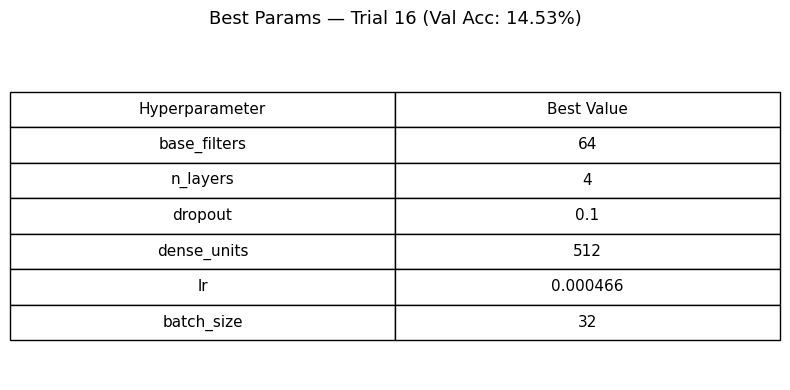

In [ ]:
params = {
    'base_filters': 64,
    'n_layers': 4,
    'dropout': 0.1,
    'dense_units': 512,
    'lr': 0.000466,
    'batch_size': 32
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table_data = [[k, v] for k, v in params.items()]
table = ax.table(
    cellText=table_data,
    colLabels=['Hyperparameter', 'Best Value'],
    cellLoc='center',
    loc='center'
)
table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(11)
plt.title('Best Params — Trial 16 (Val Acc: 14.53%)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

## What Optuna Learned

Analysis of the top-performing trials revealed several consistent patterns:

- **base_filters = 64** appeared in all of the best configurations. Within the tested search space, larger feature map capacity consistently produced better results for the 120-class classification task.
- **n_layers = 4** consistently outperformed shallower architectures (2–3 layers), suggesting that increased depth improved the model's ability to learn more discriminative features.
- **dropout = 0.1** generally performed better than 0.3 and 0.4. This suggests that stronger regularization reduced the model's learning capacity and led to underfitting rather than improved generalization.
- **Learning rates between approximately 0.0004 and 0.0007** produced the highest validation accuracies, providing a balance between stable convergence and effective learning.
- **batch_size = 32** slightly outperformed larger batch sizes, indicating that smaller batches may have provided better generalization on this dataset.

A particularly strong trend was observed for the learning rate. Several early trials using learning rates above 0.003 achieved validation accuracies close to random guessing (~1.17%), indicating unstable optimization and poor convergence. Similar behavior was observed during manual tuning, reinforcing the conclusion that **learning rate was the most influential hyperparameter within the explored search space**.

Overall, Optuna successfully identified a consistent set of high performing hyperparameters. However, the relatively small performance gap between the best manually tuned model and the best Optuna trial suggests that the architecture itself had become the primary limiting factor, rather than the choice of hyperparameters.

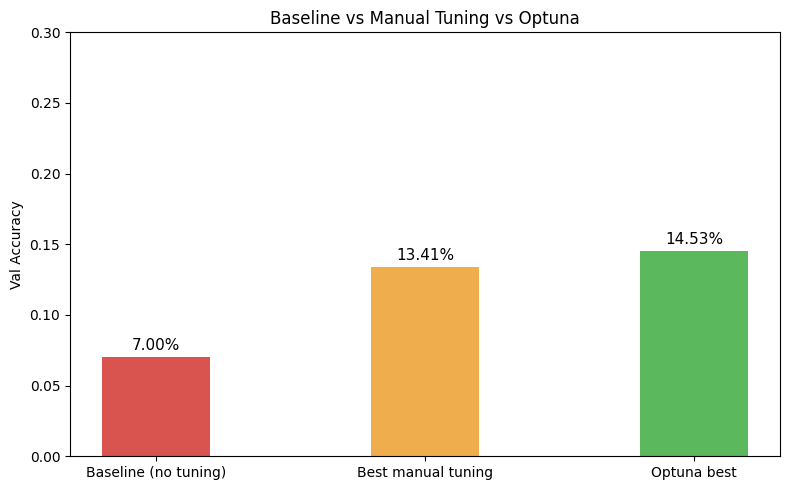

In [ ]:
comparison = {
    'Baseline (no tuning)': 0.07,
    'Best manual tuning': 00.1341,
    'Optuna best': 0.1453
}

plt.figure(figsize=(8, 5))
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
bars = plt.bar(comparison.keys(), comparison.values(), color=colors, width=0.4)
plt.ylabel('Val Accuracy')
plt.title('Baseline vs Manual Tuning vs Optuna')
plt.ylim(0, 0.3)
for bar, val in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.2%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## **Conclusion**

Optuna's best result (14.53%) is roughly on par with the best manual configuration.
This is actually a meaningful finding it shows that:

1. **Optuna didn't magically outperform careful manual tuning** — with only 20 trials
   and 8 epochs each, Bayesian search doesn't always beat a human who already has intuition
   about the problem

2. **The search space matters more than the algorithm** — Optuna can only find good configs
   within the space you define. If the architecture itself is the bottleneck (which it is
   for scratch CNNs on 120 classes), no amount of tuning fixes that

3. **Where Optuna genuinely wins** — it found the right combination of dropout=0.1 +
   lr=0.000466 + batch_size=32 together, which would have taken many more manual experiments
   to discover by changing one parameter at a time

The real ceiling for scratch CNNs on this dataset is around 15%.
Transfer learning (notebook 7) will show what's actually possible.

## Best Configuration Found
**Trial 16 — val accuracy 14.53%**